# Task : Customer Segmentation

**Dataset:** Mall Customer Dataset

**Objective:**
Group customers based on behavior using:

* Data preprocessing
* K-Means clustering
* Cluster visualization

**Output:**
Customer segments with insights.

***Import Libraries***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

***Load Dataset***

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

In [5]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


**Select Important Features**

* Annual Income
* Spending Score

In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

***Feature Scaling***

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

***Find Optimal Number of Clusters***

*Elbow Method*

In [8]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

***Plot Elbow Graph***

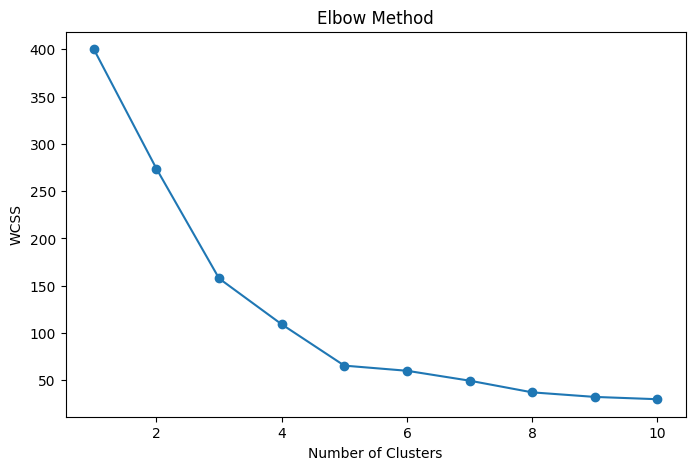

In [9]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### **Apply K-Means Clustering**

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [11]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


# **Visualize Clusters**

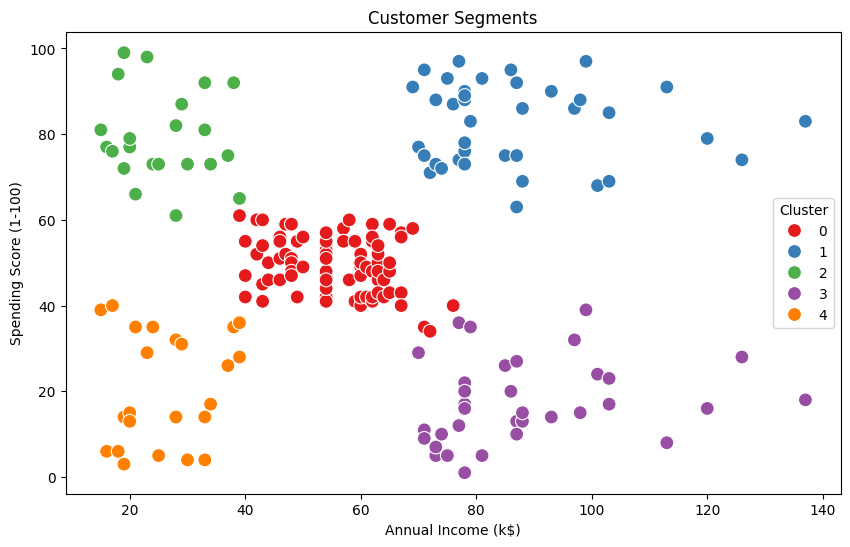

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title("Customer Segments")
plt.show()

# **Visualize Cluster Centers**

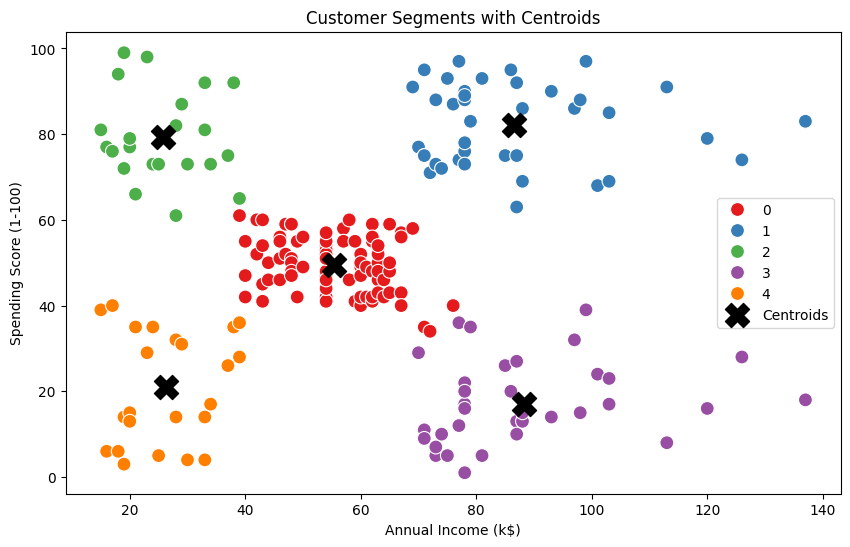

In [13]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.legend()
plt.title("Customer Segments with Centroids")
plt.show()

# **Analyze Each Cluster**

In [14]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


## **Insights**

1. Customers were divided into 5 distinct groups.
2. Some customers have high income and high spending scores.
3. Some customers earn high income but spend less.
4. Low-income low-spending customers form another segment.
5. Businesses can target each segment differently for marketing.

## **Conclusion**

Customer segmentation was successfully performed using K-Means clustering.
The customers were grouped into different segments based on annual income
and spending score. These insights can help businesses improve marketing
strategies and customer targeting.

In [16]:
df.to_csv("Mall_Customers_Segmented.csv", index=False)